# ApexPlanet Internship - Task 1

## Foundational Setup & Exploratory Data Analysis (EDA)

Prepared by: Khushi Vig

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment setup successful!")

Environment setup successful!


In [2]:
df = pd.read_excel("../data/raw/sample_-_superstore.xlsx")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
df.shape

(10194, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

| Column | Type | Description |
|---|---|---|
| Row ID | int | Unique row identifier |
| Order ID | object | Unique order identifier |
| Order Date | datetime | Date order was placed |
| Ship Date | datetime | Date order was shipped |
| Ship Mode | object | Shipping method used |
| Customer ID / Name | object | Customer identifiers |
| Segment | object | Consumer / Corporate / Home Office |
| City, State, Region | object | Delivery location |
| Category, Sub-Category, Product Name | object | Product details |
| Sales | float | Sales value for that line item |
| Quantity | int | Units sold |
| Discount | float | Discount applied (0 to 0.8) |
| Profit | float | Profit earned (can be negative) |

# Dataset Selection and Overview

## Dataset Chosen

For this project, the Sample Superstore Dataset was selected from Tableau's sample datasets. This dataset contains transactional records of a retail superstore, including customer information, product details, sales, discounts, profits, shipping methods, and geographical data.

## Reason for Selection

The dataset was chosen because it provides a comprehensive view of retail business operations and contains both numerical and categorical variables, making it well-suited for Exploratory Data Analysis (EDA). It enables the analysis of sales performance, customer segments, product categories, regional trends, and profitability patterns.

## Data Loading

The dataset was imported into a Pandas DataFrame using the `read_excel()` function. After loading, the dataset structure was examined using methods such as `head()`, `shape()`, `columns`, and `info()` to understand its contents and data types.

## Dataset Structure

The dataset contains 10,194 records and 21 features. The features include order information, customer details, product information, sales metrics, and profit-related variables. The dataset contains:

* 2 datetime columns
* 3 numerical columns related to business performance
* Multiple categorical columns describing customers, products, and locations

## Data Source

Source: Tableau Sample Superstore Dataset

The dataset represents historical retail transactions from a superstore business environment and is commonly used for business intelligence, dashboarding, and data analytics practice.

## Data Collection Method

The dataset consists of transactional sales records where each row represents an individual product sale. The information includes order details, shipping information, customer demographics, product categories, revenue generated, discounts applied, and profit earned from each transaction.

## Limitations

* The dataset is a sample dataset created for educational and analytical purposes.
* It may not fully represent real-world retail operations or current market conditions.
* The data covers a specific business environment and geographical scope.
* External factors such as seasonality, economic conditions, and customer behaviour changes are not explicitly included.

## Objective of Analysis

The primary objective of this analysis is to explore patterns in sales and profitability, identify trends across customer segments and product categories, detect anomalies, and generate actionable business insights through Exploratory Data Analysis (EDA).


In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [7]:
df.duplicated().sum()

0

### Missing Values and Duplicate Check

Before doing anything else, I wanted to make sure the data itself was clean. I ran `df.isnull().sum()` to check for missing values across all 21 columns, and nothing came back; every column showed 0. I also ran `df.duplicated().sum()` to check for duplicate rows, and that came back 0 too. So this dataset didn't require any missing-value handling or deduplication, which made the next steps much simpler.

In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [9]:
categorical_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
df[categorical_cols] = df[categorical_cols].astype('category')

df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode               category
Customer ID               object
Customer Name             object
Segment                 category
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Region                  category
Product ID                object
Category                category
Sub-Category            category
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

### Fixing Data Types

Ship Mode, Segment, Region, Category, and Sub-Category were all stored as plain object/text columns, even though each one only has a small set of repeating values (like Consumer/Corporate/Home Office for Segment). I converted these to the category dtype instead. It doesn't change any values; it just makes grouping and plotting a bit faster and is the more correct way to store this kind of data.

In [10]:
def iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]

profit_outliers = iqr_outliers(df, 'Profit')
sales_outliers = iqr_outliers(df, 'Sales')

print(f"Number of Profit outliers: {len(profit_outliers)}")
print(f"Number of Sales outliers: {len(sales_outliers)}")

Number of Profit outliers: 1913
Number of Sales outliers: 1183


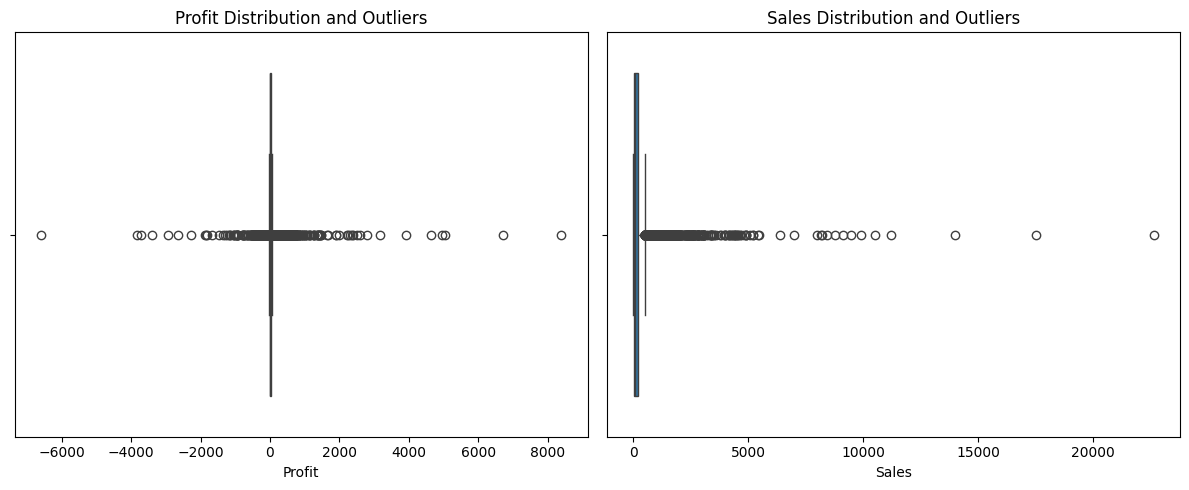

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=df['Profit'], ax=axes[0])
axes[0].set_title('Profit Distribution and Outliers')

sns.boxplot(x=df['Sales'], ax=axes[1])
axes[1].set_title('Sales Distribution and Outliers')

plt.tight_layout()
plt.show()

### Outlier Detection (IQR Method)

I used the IQR method to flag outliers in Profit and Sales. Profit came back with 1,913 outlier rows (about 18.8% of the data), and Sales had 1,183 (about 11.6%). That's a pretty big chunk of the dataset, way more than I expected, so I don't think these are mistakes in the data. They're more likely real bulk orders and big discount-driven losses, which is just how retail sales tend to look.

Because of that, I decided not to remove them. A -$6,599 loss is still a real transaction that actually happened; removing it would just be hiding a problem instead of looking at it, which kind of defeats the point of doing EDA in the first place.

### Data Cleaning Summary

The following cleaning steps were carried out on the dataset before analysis:

1. **Missing values:** Checked across all 21 columns using `isnull().sum()`. No missing values were found, so no imputation was required.
2. **Duplicate rows:** Checked using `duplicated().sum()`. No duplicate rows were found, so no deduplication was required.
3. **Data types:** Ship Mode, Segment, Region, Category, and Sub-Category were converted from object to category type, since each contains a limited, repeating set of values.
4. **Outliers:** Checked in Sales and Profit using the IQR method. 1,913 rows were flagged as Profit outliers and 1,183 as Sales outliers. These were retained rather than removed, as they represent genuine business events (bulk orders, heavy discounts, and losses) rather than data entry errors.

Overall, the dataset required minimal cleaning, as it was already well-structured. The main adjustments were correcting data types and documenting the presence of outliers for consideration during analysis.

### Cleaning Log

The table below summarises all data cleaning operations performed on the dataset prior to analysis.

| Step | Action Taken |
|---|---|
| Missing Values | Checked using `isnull().sum()`; no missing values found across all 21 columns |
| Duplicate Rows | Checked using `duplicated().sum()`; no duplicate rows found |
| Data Types | Converted Ship Mode, Segment, Region, Category, and Sub-Category from object to category type |
| Outliers | Identified using the IQR method; 1,913 Profit outliers and 1,183 Sales outliers found and retained, as they represent genuine business transactions rather than data errors |
| Column Names | No renaming required; original column names were already clear and consistent |

In [12]:
for col in ['Segment', 'Region', 'Category', 'Sub-Category', 'Ship Mode']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Segment value counts:
Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

Region value counts:
Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64

Category value counts:
Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

Sub-Category value counts:
Sub-Category
Binders        1548
Paper          1384
Furnishings    1009
Phones          903
Storage         856
Art             821
Accessories     775
Chairs          634
Appliances      474
Labels          368
Tables          326
Envelopes       256
Bookcases       232
Fasteners       229
Supplies        192
Machines        117
Copiers          70
Name: count, dtype: int64

Ship Mode value counts:
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64


### Categorical Variable Summary

A `value_counts()` check was run on the key categorical columns to understand the composition of the dataset. Consumer is the dominant segment with 5,281 orders, more than the Corporate (3,090) and Home Office (1,823) segments combined. Regionally, West leads with 3,253 orders followed closely by East at 2,986, while South trails at just 1,620. Within Category, Office Supplies dominates with 6,128 orders, roughly three times that of Furniture (2,201) and Technology (1,865). At the Sub-Category level, Binders (1,548) and Paper (1,384) are the most frequently ordered items, which makes sense given how often office supplies are restocked, while Copiers (70) and Machines (117) are ordered far less often, as expected for big-ticket, infrequent purchases. Standard Class is by far the most common shipping mode (6,120 orders), suggesting most customers are not paying for expedited delivery.

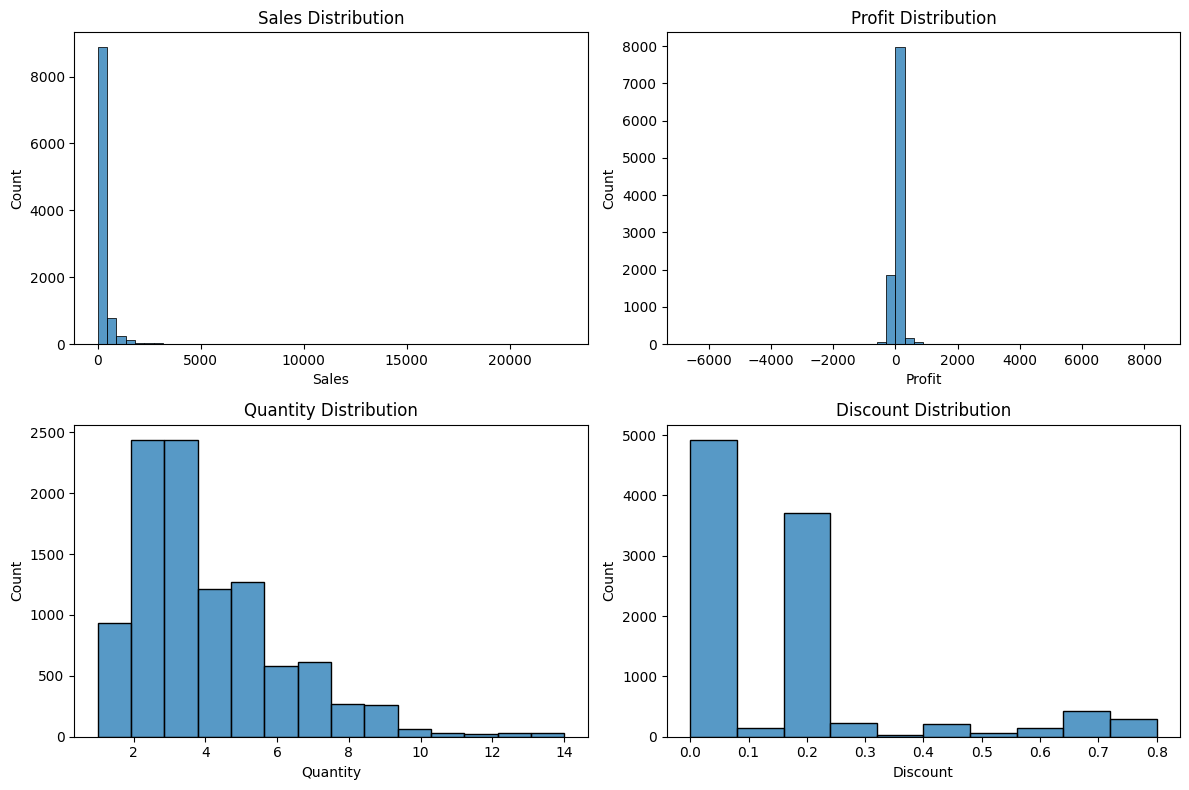

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['Sales'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Sales Distribution')

sns.histplot(df['Profit'], bins=50, ax=axes[0,1])
axes[0,1].set_title('Profit Distribution')

sns.histplot(df['Quantity'], bins=14, ax=axes[1,0])
axes[1,0].set_title('Quantity Distribution')

sns.histplot(df['Discount'], bins=10, ax=axes[1,1])
axes[1,1].set_title('Discount Distribution')

plt.tight_layout()
plt.show()

### Univariate Analysis: Numeric Distributions

Looking at the four histograms:

Sales is heavily skewed to the right; most orders are under 1,000, but there's a long tail of a few orders going all the way up to 20,000+. So a small number of big orders are stretching the chart out.

Profit is mostly clustered right around 0, meaning most orders make a small profit. There's a thin tail on both sides, though: some orders lose money, some make a lot, but most are just kind of average.

Quantity ranges from 1 to 14 per order, and most orders are for 2 or 3 units. Not many people order 10+ units at once.

Discount is a bit different since it's not a smooth distribution; it's grouped into specific values. Most orders have 0 discount, then 0.2 is the next most common. The other discount levels (0.4, 0.6, 0.7, 0.8) show up way less, so it looks like the business sticks to a few fixed discount rates instead of randomly discounting.

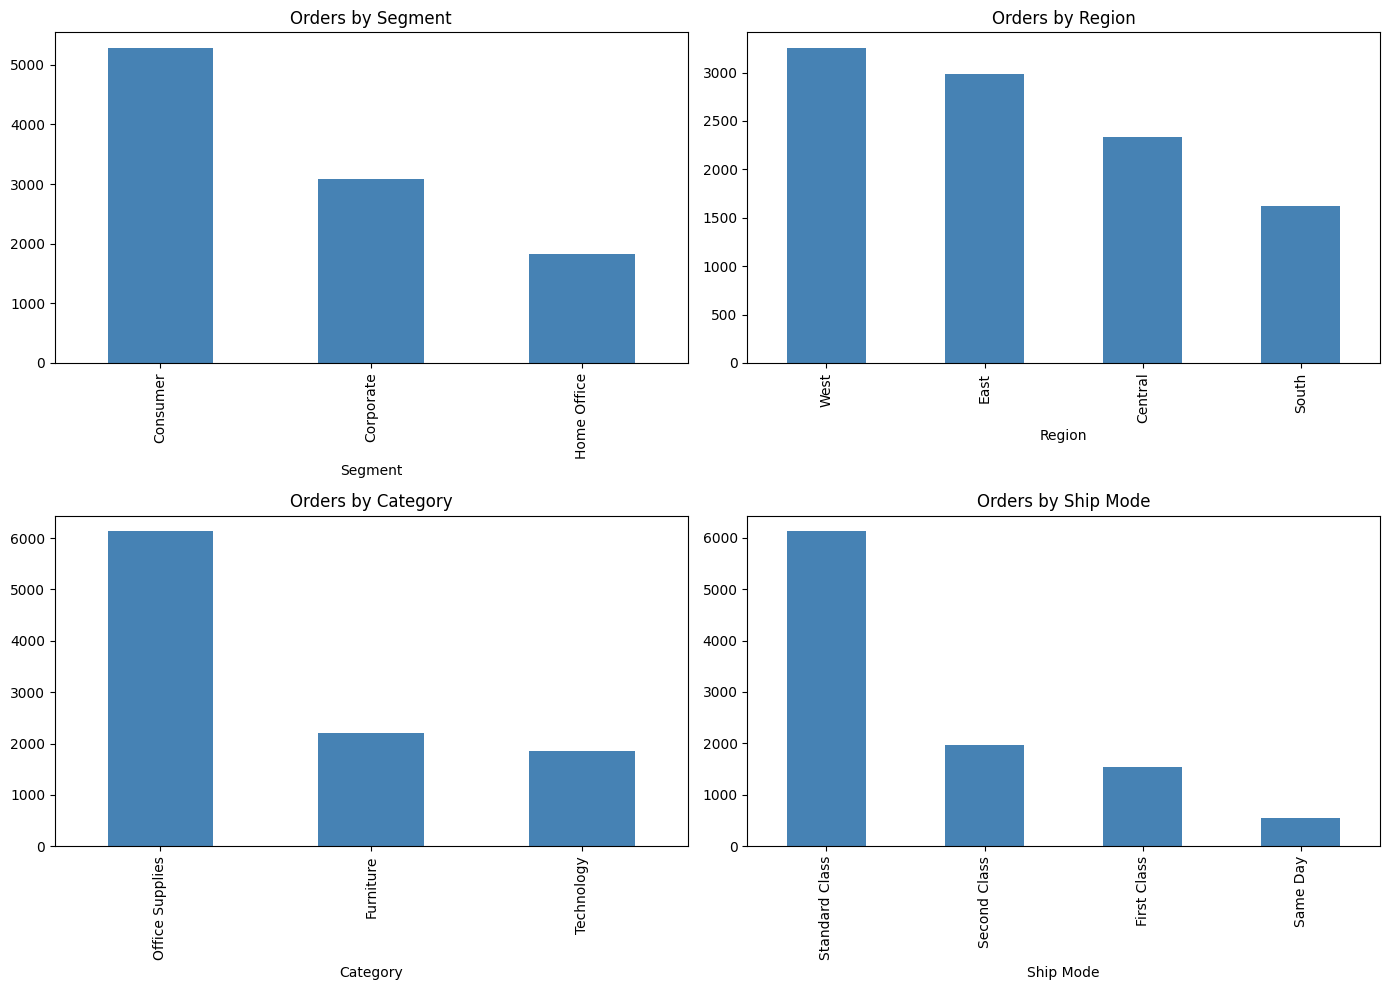

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['Segment'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Orders by Segment')

df['Region'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Orders by Region')

df['Category'].value_counts().plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Orders by Category')

df['Ship Mode'].value_counts().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Orders by Ship Mode')

plt.tight_layout()
plt.show()

### Univariate Analysis: Categorical Distributions

These bar charts are basically the value_counts numbers from earlier, but easier to actually see. Consumer, West, Office Supplies, and Standard Class are all clearly the biggest bars in their respective charts, so nothing new here- just a visual version of what I already found.

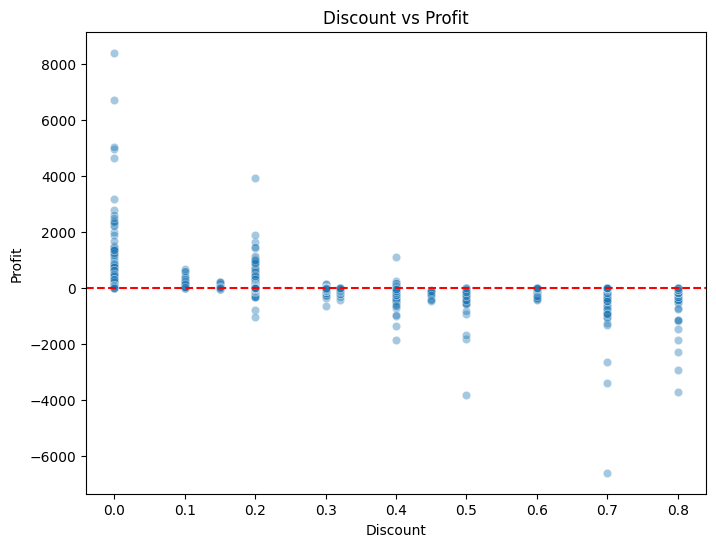

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4)
plt.title('Discount vs Profit')
plt.axhline(0, color='red', linestyle='--')
plt.show()

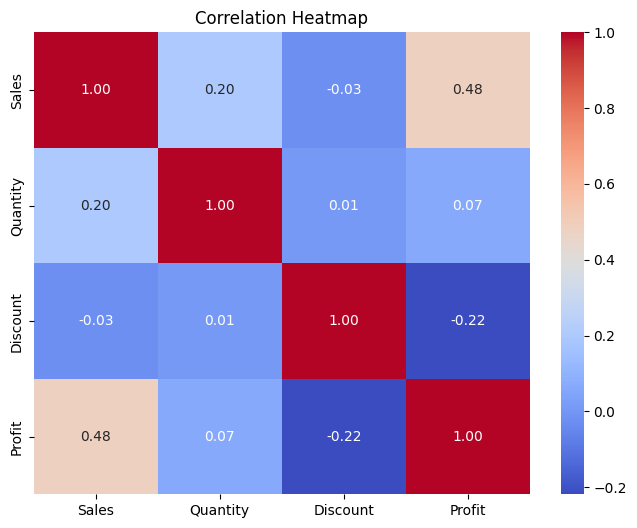

In [16]:
plt.figure(figsize=(8,6))
correlation_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Bivariate Analysis: Discount, Profit, and Correlations

The Discount vs Profit scatter plot reveals a clear inverse pattern. At low discounts (0.0), profit is mostly positive, and this is where every one of the dataset's highest-profit orders appears (up to roughly 8,400). As discount increases beyond 0.3 to 0.4, points increasingly fall below the zero line, and by 0.7 to 0.8 discount, almost every order results in a loss, including the single largest loss in the dataset (around -6,600 at a 0.7 discount). This suggests heavy discounting is a major driver of unprofitable transactions.

The correlation heatmap supports this numerically. Discount and Profit have a correlation of -0.22, a moderate negative relationship confirming that higher discounts tend to coincide with lower profit. Sales and Profit show a moderate positive correlation of 0.48, meaning larger sales transactions tend to be more profitable overall. Sales and Quantity have a weaker positive correlation of 0.20, while Quantity shows almost no relationship with either Discount (0.01) or Profit (0.07). Overall, Discount stands out as the variable most associated with reduced profitability.

## Key Findings

1. **Discounting drives losses.** Orders with discounts above 0.5 are overwhelmingly loss-making, while orders with no or low discount are mostly profitable. Discount and Profit have a negative correlation of -0.22.
2. **A small number of large orders dominate Sales.** The Sales distribution is heavily right-skewed, with most orders under 1,000 but a long tail of large transactions reaching over 20,000.
3. **Office Supplies and Consumer segment dominate order volume.** Office Supplies accounts for 6,128 of 10,194 orders, and Consumer is the largest segment with 5,281 orders, but high order volume in a category does not guarantee high profitability per order.
4. **Outliers reflect genuine business events, not data errors.** Both Sales and Profit contain a notable share of statistical outliers (11.6% and 18.8%, respectively), but these largely represent real bulk orders and heavily discounted transactions rather than data quality issues.

In [17]:
df.to_csv("../data/processed/cleaned_superstore.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


### Saving the Cleaned Dataset

After completing the data cleaning and preprocessing steps, the cleaned dataset was saved to the `data/processed/` folder as `cleaned_superstore.csv`.

Keeping the processed dataset separate from the original raw dataset helps maintain the original data while providing a ready-to-use version for future analysis and reporting.